# Workshop 2: Análisis de Spotify y Grammys

En este notebook vamos a analizar los datos procesados por nuestro pipeline ETL de Airflow. Los datos ya pasaron por limpieza, validación (Pandera) y el cruce entre Spotify y los ganadores de los Grammys, y ahora están alojados en nuestra base de datos local SQLite.

El objetivo es responder: **¿Qué características tienen los artistas y las canciones ganadoras de Grammys dentro de Spotify?**

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import os

db_path = os.path.join('..', 'db', 'musica_destino.db')
conn = sqlite3.connect(db_path)

color_grammy = '#2a78d6'   
color_sin_grammy = '#eb6834' 
colores = [color_grammy, color_sin_grammy]

print("Conexión exitosa a la base de datos:", db_path)

Conexión exitosa a la base de datos: ..\db\musica_destino.db


## 1. Popularidad Promedio: ¿Tener un Grammy te hace más popular en Spotify?
Vamos a comparar la métrica `popularity` que nos da Spotify para ambos grupos de canciones.

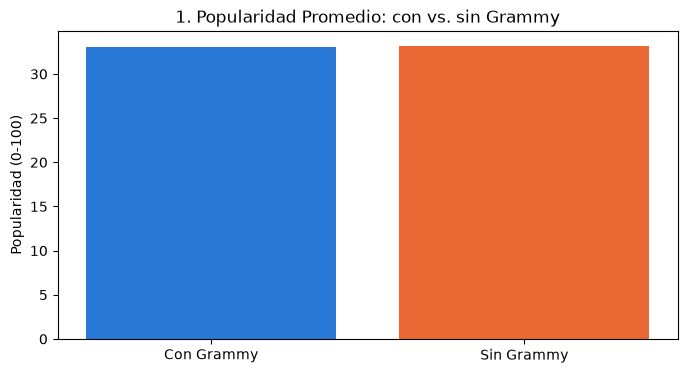

In [2]:
query_pop = """
    SELECT CASE WHEN has_grammy = 1 THEN 'Con Grammy' ELSE 'Sin Grammy' END AS grupo,
           AVG(popularity) AS popularidad_promedio,
           COUNT(*) AS canciones
    FROM spotify_grammys 
    GROUP BY grupo 
    ORDER BY grupo
"""
df_pop = pd.read_sql(query_pop, conn)

plt.figure(figsize=(8, 4))
plt.bar(df_pop['grupo'], df_pop['popularidad_promedio'], color=colores)
plt.title('1. Popularidad Promedio: con vs. sin Grammy')
plt.ylabel('Popularidad (0-100)')
plt.show()

**Análisis:** Curiosamente, la popularidad promedio es prácticamente idéntica (~33 puntos). Esto rompe nuestro mito inicial: ganar un Grammy no significa automáticamente que tus canciones se escuchen masivamente en la era del streaming (Spotify). Hay muchas canciones virales de artistas sin Grammy que nivelan este promedio.

## 2. Top 10 Artistas con más Grammys en Spotify
Queremos ver quiénes son los pesos pesados de la industria musical que logramos cruzar en nuestro dataset.

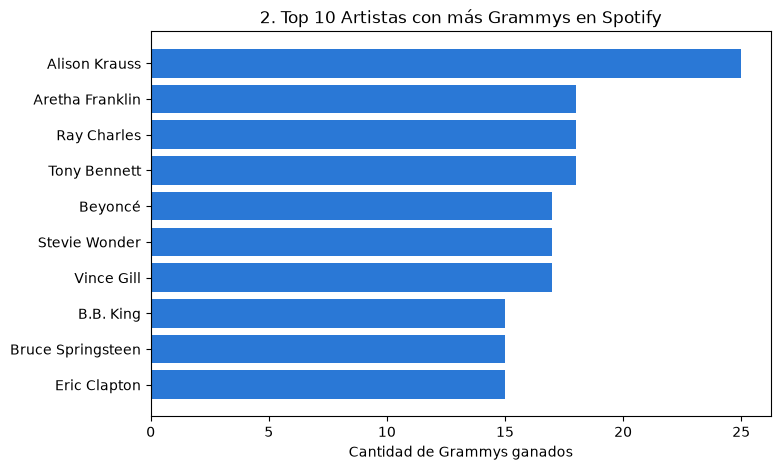

In [ ]:
query_top = """
    SELECT main_artist, MAX(grammy_wins) AS grammys
    FROM spotify_grammys 
    WHERE has_grammy = 1
    GROUP BY artist_key 
    ORDER BY grammys DESC 
    LIMIT 10
"""
df_top = pd.read_sql(query_top, conn)
df_top = df_top.iloc[::-1] 

plt.figure(figsize=(8, 5))
plt.barh(df_top['main_artist'], df_top['grammys'], color=color_grammy)
plt.title('2. Top 10 Artistas con más Grammys en Spotify')
plt.xlabel('Cantidad de Grammys ganados')
plt.show()